In [1]:
import pandas as pd
import numpy as np

%matplotlib inline
# matplotlib.use('TkAgg')  # or 'QtAgg', etc.

import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science', 'ieee'])

# Increase fonts globally (adjust sizes as needed)
# DEFAULT IS 12
plt.rcParams.update({
    'font.size': 15,            # default text size
    'axes.titlesize': 15,      # axes title
    'axes.labelsize': 15,      # x/y labels
    'xtick.labelsize': 15,     # x tick labels
    'ytick.labelsize': 15,     # y tick labels
    'legend.fontsize': 15,     # legend text
    'figure.titlesize': 15
})

In [2]:
df_vvo = pd.read_csv('data/log_10_2025-10-13-21-54-08_vehicle_visual_odometry_0.csv')
df_vo = pd.read_csv('data/log_10_2025-10-13-21-54-08_vehicle_odometry_0.csv')

In [3]:
t_vvo = (df_vvo['timestamp'].to_numpy() - df_vvo['timestamp'].to_numpy()[0]) / 1e6
t_vo = (df_vo['timestamp'].to_numpy() - df_vo['timestamp'].to_numpy()[0]) / 1e6
pos1_vvo = df_vvo['position[0]'].to_numpy()
pos1_vo = df_vo['position[0]'].to_numpy()
pos3_vvo = -df_vvo['position[1]'].to_numpy()
pos3_vo = -df_vo['position[1]'].to_numpy()
pos2_vvo = df_vvo['position[2]'].to_numpy()
pos2_vo = df_vo['position[2]'].to_numpy()

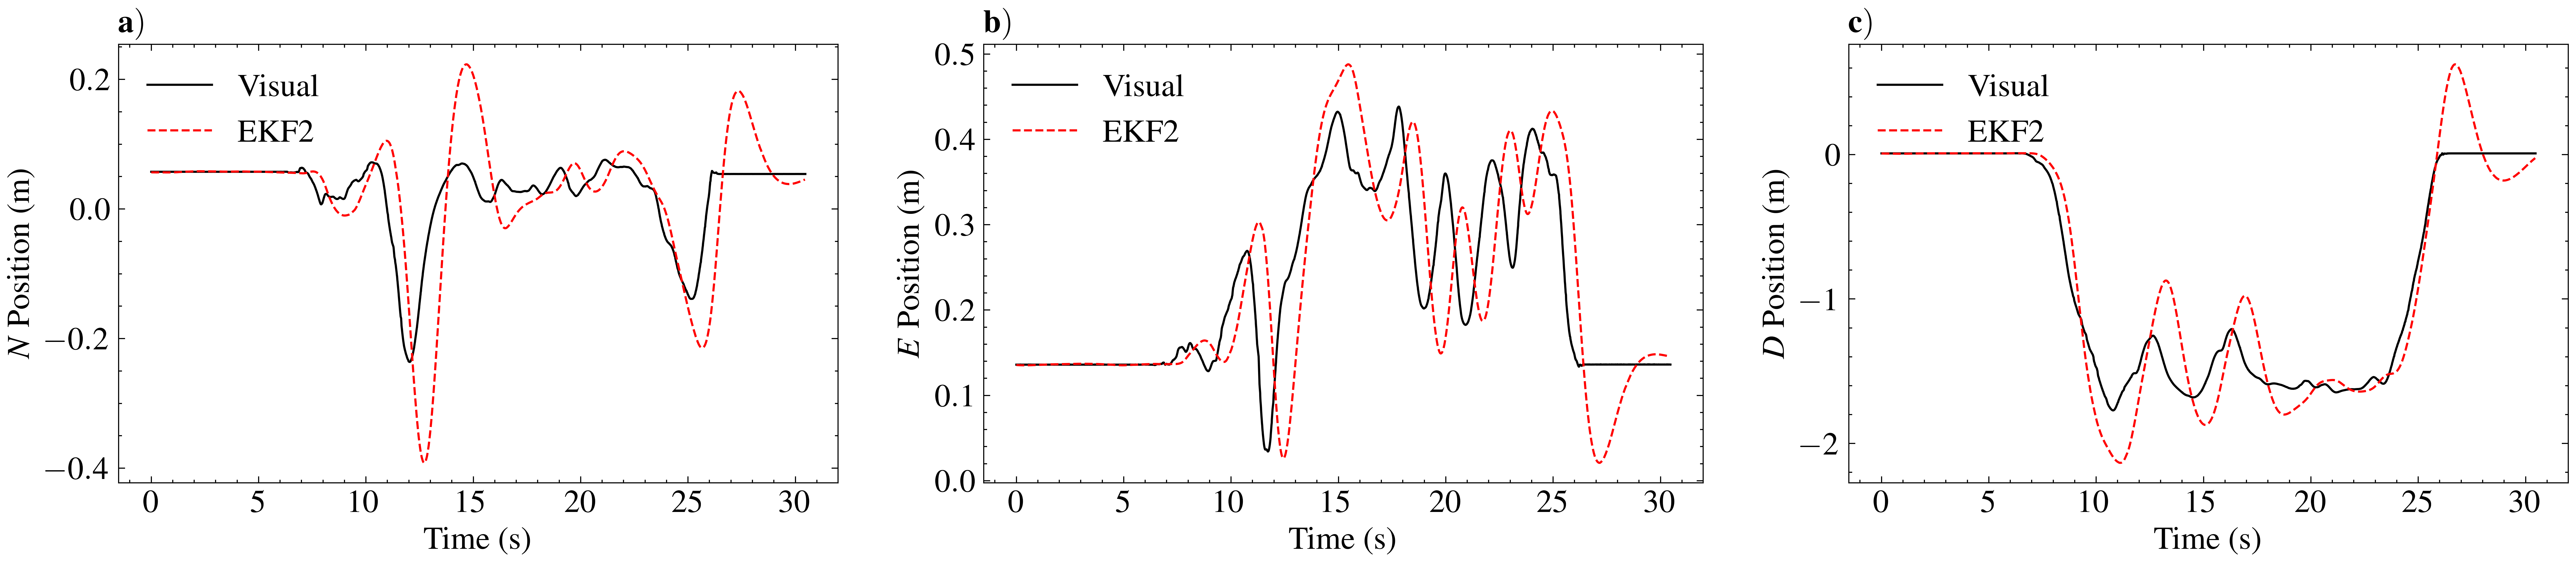

In [4]:
# Plot position 1 (N), 2 (E), 3 (D) comparisons
plt.figure(figsize=(17, 4))
plt.subplot(1,3,1)
plt.plot(t_vvo, pos1_vvo, label='Visual')
plt.plot(t_vo, pos1_vo, label='EKF2', linestyle='--')
plt.title(r'$\bf{a)}$', loc='left')
plt.xlabel("Time (s)")
plt.ylabel("$N$ Position (m)")
plt.legend(loc='upper left')
plt.subplot(1,3,2)
plt.plot(t_vvo, pos2_vvo, label='Visual')
plt.plot(t_vo, pos2_vo, label='EKF2', linestyle='--')
plt.title(r'$\bf{b)}$', loc='left')
plt.xlabel("Time (s)")
plt.ylabel("$E$ Position (m)")
plt.legend(loc='best')
plt.subplot(1,3,3)
plt.plot(t_vvo, pos3_vvo, label='Visual')
plt.plot(t_vo, pos3_vo, label='EKF2', linestyle='--')
plt.title(r'$\bf{c)}$', loc='left')
plt.xlabel("Time (s)")
plt.ylabel("$D$ Position (m)")
plt.legend(loc='upper left')
plt.savefig("vvo_vs_ekf2_positions_1.pdf", bbox_inches='tight')
plt.tight_layout()
plt.show()